[Dataset](https://www.kaggle.com/datasets/bytadit/ecommerce-order-dataset/data)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_orders = pd.read_csv('df_Orders.csv')
df_orderitems = pd.read_csv('df_OrderItems.csv')
df_customer = pd.read_csv('df_Customers.csv')
df_products = pd.read_csv('df_Products.csv')
df_payments = pd.read_csv('df_Payments.csv')

### Проверка Orders

#### План проверки
* Проверить уникальность order_id, количество дубликатов.
* Посчитать распределение по order_status (доля delivered, canceled и т.д.).
* Проверить пропуски по ключевым датам (order_purchase_timestamp, order_approved_at, order_delivered_timestamp).
* Рассчитать длительность этапов: purchase→approved, approved→delivered, purchase→estimated_delivery, сравнить распределения.
* Проверить аномальные отрицательные или слишком большие длительности (заказ «доставлен до покупки» и т.п.).
* Посмотреть динамику количества заказов по дням/неделям/месяцам.
* Проверить, есть ли заказы без customer_id.
* Проверить, есть ли статусы, не описанные в документации набора (опечатки, лишние категории).
* Посчитать среднее/медиану длительности доставки по статусу (только delivered).
* Посмотреть распределение заказов по часовым интервалам в течение дня (в какое время чаще покупают).

In [4]:
df_orders.shape

(89316, 7)

In [5]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18


In [6]:
df_orders.tail()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date
89311,zlcLnXGgAabl,bfJtzkBGksdY,delivered,2018-08-19 17:25:36,2018-08-21 04:35:30,2018-08-30 14:47:46,2018-09-04
89312,IlTAoIkILwrq,4hjsCpj6FC7g,delivered,2017-12-15 11:20:27,2017-12-16 02:37:32,2017-12-20 19:23:40,2018-01-04
89313,uA6oXfftGVmT,DLn56oKHl9bv,delivered,2018-07-24 06:39:14,2018-07-24 11:20:39,2018-07-27 01:41:40,2018-08-01
89314,v3QtU6xlGDJp,auSfRYUQUOIq,delivered,2018-08-11 08:04:22,2018-08-11 08:24:40,2018-08-14 21:43:51,2018-08-17
89315,Xo1fqyXOC6CR,rhevVNXYJnEs,delivered,2018-06-09 21:46:58,2018-06-09 22:19:00,2018-06-14 15:03:46,2018-07-05


In [7]:
df_orders.sample(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date
77989,jm0nfSqOKpYI,s4j61latfyro,delivered,2017-12-04 16:22:29,2017-12-05 04:15:39,2017-12-21 22:27:07,2017-12-28
27200,A1MxkYBfCIXW,NxztuNWLsv4p,delivered,2017-12-23 13:54:58,2017-12-23 14:29:53,2018-01-05 20:58:59,2018-01-22
68073,Yq50ARLDwUnf,qyZYQKUMp5S8,delivered,2017-07-07 21:59:57,2017-07-07 22:43:21,2017-07-17 19:13:55,2017-07-27
769,4XD3XsJnUFnM,5h0kQ0HMhfFf,delivered,2018-04-27 20:41:03,2018-04-27 20:55:31,2018-05-03 18:32:14,2018-05-16
67639,j4bSEYUNYH6I,aK898G3vQi2l,delivered,2018-06-25 09:53:57,2018-06-25 10:14:04,2018-07-09 23:04:31,2018-07-24
33798,HnJyUO2sCORS,j2jnYEngouRp,delivered,2018-08-10 16:28:54,2018-08-10 16:44:29,2018-08-16 18:51:00,2018-08-23
16154,tgzHdvMSg23Z,aCPUSpYf14q5,delivered,2017-05-28 15:04:14,2017-05-28 15:15:19,2017-06-07 14:59:41,2017-06-21
22912,rboVwzfymio7,X9m2WoKOD5CS,delivered,2017-11-16 00:03:35,2017-11-16 00:26:51,2017-12-06 17:07:42,2017-12-15
64080,zWCxBRfm8UkU,tWqoBHacan0h,shipped,2018-02-03 17:55:52,2018-02-03 20:10:14,NaN,2018-03-08
6152,Jg0tDkezERQr,KGAMPh3w3GWY,delivered,2018-04-11 13:27:29,2018-04-11 13:50:26,2018-04-30 15:51:46,2018-05-25


In [8]:
df_orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_timestamp',
       'order_estimated_delivery_date'],
      dtype='str')

In [9]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 89316 entries, 0 to 89315
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       89316 non-null  str  
 1   customer_id                    89316 non-null  str  
 2   order_status                   89316 non-null  str  
 3   order_purchase_timestamp       89316 non-null  str  
 4   order_approved_at              89307 non-null  str  
 5   order_delivered_timestamp      87427 non-null  str  
 6   order_estimated_delivery_date  89316 non-null  str  
dtypes: str(7)
memory usage: 4.8 MB


In [10]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_timestamp',
    'order_estimated_delivery_date'
]

df_orders[date_cols] = df_orders[date_cols].apply(pd.to_datetime)

In [11]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 89316 entries, 0 to 89315
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       89316 non-null  str           
 1   customer_id                    89316 non-null  str           
 2   order_status                   89316 non-null  str           
 3   order_purchase_timestamp       89316 non-null  datetime64[us]
 4   order_approved_at              89307 non-null  datetime64[us]
 5   order_delivered_timestamp      87427 non-null  datetime64[us]
 6   order_estimated_delivery_date  89316 non-null  datetime64[us]
dtypes: datetime64[us](4), str(3)
memory usage: 4.8 MB


In [12]:
df_orders.nunique()

order_id                         89316
customer_id                      89316
order_status                         7
order_purchase_timestamp         72775
order_approved_at                68215
order_delivered_timestamp        71143
order_estimated_delivery_date      444
dtype: int64

In [13]:
df_orders.duplicated().sum()

np.int64(0)

In [14]:
df_orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   9
order_delivered_timestamp        1889
order_estimated_delivery_date       0
dtype: int64

In [15]:
df_orders['order_id'].value_counts()

order_id
Axfy13Hk4PIk    1
v6px92oS8cLG    1
Ulpf9skrhjfm    1
bwJVWupf2keN    1
Dd0QnrMk9Cj5    1
               ..
zlcLnXGgAabl    1
IlTAoIkILwrq    1
uA6oXfftGVmT    1
v3QtU6xlGDJp    1
Xo1fqyXOC6CR    1
Name: count, Length: 89316, dtype: int64

In [16]:
df_orders['order_id'].value_counts().loc[lambda x: x > 1]

Series([], Name: count, dtype: int64)

In [17]:
df_orders['order_status'].value_counts()

order_status
delivered      87428
shipped          936
canceled         409
processing       273
invoiced         266
unavailable        2
approved           2
Name: count, dtype: int64

In [18]:
df_orders['order_status'].value_counts(normalize=True) * 100

order_status
delivered      97.886157
shipped         1.047965
canceled        0.457925
processing      0.305656
invoiced        0.297819
unavailable     0.002239
approved        0.002239
Name: proportion, dtype: float64

In [19]:
status_stats = pd.concat(
    [df_orders['order_status'].value_counts(),
     (df_orders['order_status'].value_counts(normalize=True) * 100).round(2)],
     axis=1
)
status_stats.columns=['count', 'share_pct']
status_stats

,count,share_pct
order_status,,
delivered,87428,97.89
shipped,936,1.05
canceled,409,0.46
processing,273,0.31
invoiced,266,0.30
unavailable,2,0.00
approved,2,0.00


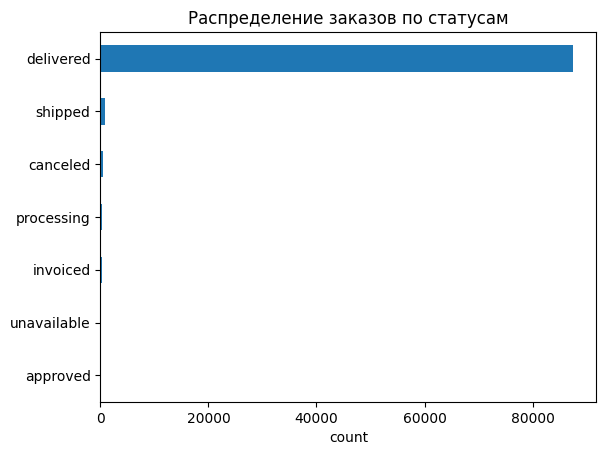

In [20]:
status_counts = df_orders['order_status'].value_counts().sort_values(ascending=True)

status_counts.plot(kind='barh', ylabel='')
plt.xlabel('count')
# plt.ylabel('order_status')
plt.title('Распределение заказов по статусам')
plt.show()

In [21]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_timestamp',
    'order_estimated_delivery_date'
]

missing_dates_cnt = df_orders[date_cols].isna().sum()
missing_dates_pct = (df_orders[date_cols].isna().mean() * 100).round(2)

missing_dates_stats = pd.concat([missing_dates_cnt, missing_dates_pct], axis=1)
missing_dates_stats.columns = ['missing_count', 'missing_pct']
missing_dates_stats

,missing_count,missing_pct
order_purchase_timestamp,0,0.00
order_approved_at,9,0.01
order_delivered_timestamp,1889,2.11
order_estimated_delivery_date,0,0.00


In [22]:
df_orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_timestamp',
       'order_estimated_delivery_date'],
      dtype='str')

In [23]:
df_orders['purchase_to_approved'] = (
    df_orders['order_approved_at'] - df_orders['order_purchase_timestamp']
)

df_orders['approved_to_delivered'] = (
    df_orders['order_delivered_timestamp'] - df_orders['order_approved_at']
)

df_orders['purchase_to_estimated'] = (
    df_orders['order_estimated_delivery_date'] - df_orders['order_purchase_timestamp']
)

df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,purchase_to_approved,approved_to_delivered,purchase_to_estimated
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,0 days 00:16:19,4 days 03:05:39,17 days 05:02:06
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,0 days 00:39:49,13 days 00:31:02,33 days 02:19:29
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,0 days 23:56:04,9 days 09:14:15,19 days 07:40:29
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,0 days 00:10:47,9 days 01:48:35,31 days 05:55:31
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,0 days 00:47:27,14 days 01:51:18,26 days 07:15:56


In [24]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 89316 entries, 0 to 89315
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       89316 non-null  str            
 1   customer_id                    89316 non-null  str            
 2   order_status                   89316 non-null  str            
 3   order_purchase_timestamp       89316 non-null  datetime64[us] 
 4   order_approved_at              89307 non-null  datetime64[us] 
 5   order_delivered_timestamp      87427 non-null  datetime64[us] 
 6   order_estimated_delivery_date  89316 non-null  datetime64[us] 
 7   purchase_to_approved           89307 non-null  timedelta64[us]
 8   approved_to_delivered          87418 non-null  timedelta64[us]
 9   purchase_to_estimated          89316 non-null  timedelta64[us]
dtypes: datetime64[us](4), str(3), timedelta64[us](3)
memory usage: 6.8 MB


In [25]:
df_orders['purchase_to_approved_days'] = (
    df_orders['purchase_to_approved'] / np.timedelta64(1, 'D')
)

df_orders['approved_to_delivered_days'] = (
    df_orders['approved_to_delivered'] / np.timedelta64(1, 'D')
)

df_orders['purchase_to_estimated_days'] = (
    df_orders['purchase_to_estimated'] / np.timedelta64(1, 'D')
)

df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,purchase_to_approved,approved_to_delivered,purchase_to_estimated,purchase_to_approved_days,approved_to_delivered_days,purchase_to_estimated_days
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,0 days 00:16:19,4 days 03:05:39,17 days 05:02:06,0.011331,4.128924,17.209792
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,0 days 00:39:49,13 days 00:31:02,33 days 02:19:29,0.027650,13.021551,33.096863
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,0 days 23:56:04,9 days 09:14:15,19 days 07:40:29,0.997269,9.384896,19.319780
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,0 days 00:10:47,9 days 01:48:35,31 days 05:55:31,0.007488,9.075405,31.246887
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,0 days 00:47:27,14 days 01:51:18,26 days 07:15:56,0.032951,14.077292,26.302731


In [26]:
cols_durations = [
    'purchase_to_approved_days',
    'approved_to_delivered_days',
    'purchase_to_estimated_days'
]

df_orders[cols_durations].describe()

,purchase_to_approved_days,approved_to_delivered_days,purchase_to_estimated_days
count,89307.000000,87418.000000,89316.000000
mean,0.434641,12.002213,23.894828
std,0.920866,9.237657,8.866609
min,0.000000,-6.989653,2.008009
25%,0.008970,6.290000,18.433970
50%,0.014363,9.821933,23.270347
75%,0.619716,15.005859,28.507234
max,60.452766,208.500972,149.592280


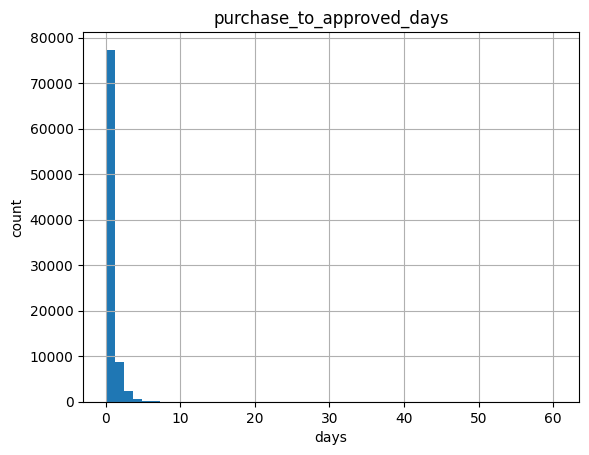

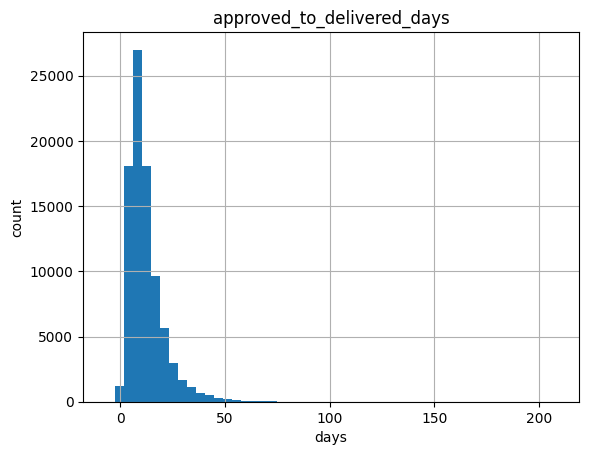

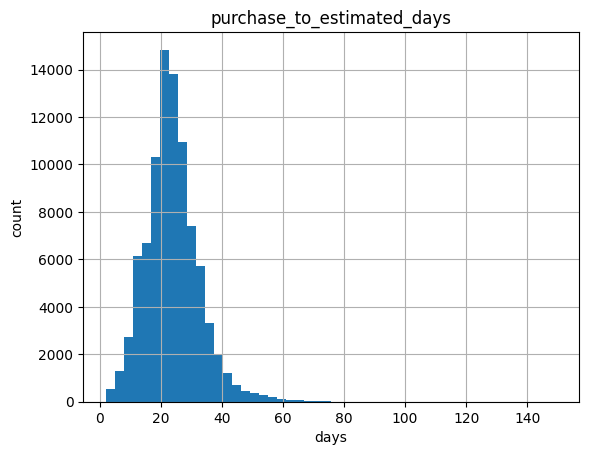

In [27]:
for col in cols_durations:
    df_orders[col].hist(bins=50)
    plt.title(col)
    plt.xlabel('days')
    plt.ylabel('count')
    plt.show()

In [28]:
neg_purchase_to_approved = (df_orders['purchase_to_approved_days'] < 0).sum()
neg_approved_to_delivered = (df_orders['approved_to_delivered_days'] < 0).sum()
neg_purchase_to_estimated = (df_orders['purchase_to_estimated_days'] < 0).sum()

In [29]:
neg_purchase_to_approved

np.int64(0)

In [30]:
neg_approved_to_delivered

np.int64(53)

In [31]:
neg_purchase_to_estimated

np.int64(0)

In [32]:
df_orders[df_orders['approved_to_delivered_days'] < 0][
    [
        'order_id',
        'order_status',
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_timestamp',
        'approved_to_delivered_days'
    ]
].head()

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,approved_to_delivered_days
732,qf88tnNyUpRx,delivered,2018-08-09 20:45:10,2018-08-20 15:56:29,2018-08-15 14:56:43,-5.041505
2734,X7BdF882u7jZ,delivered,2018-08-09 20:45:10,2018-08-20 15:56:29,2018-08-15 14:56:43,-5.041505
3311,nFPgCdm662nu,delivered,2018-07-24 11:32:11,2018-07-29 23:30:52,2018-07-27 18:55:57,-2.190914
5035,18BVSbwrvOLi,delivered,2017-06-26 12:23:32,2017-07-05 17:09:11,2017-07-03 17:53:29,-1.969236
5550,TkUmHDHxzRRF,delivered,2018-04-22 21:15:32,2018-04-24 19:24:43,2018-04-24 15:32:26,-0.161308


Пороги "аномальности" данных:
* для purchase_to_approved_days: аномально всё, что > 7 дней;
* для approved_to_delivered_days: аномально всё, что > 60 дней;
* для purchase_to_estimated_days: аномально всё, что > 90 дней (учитывая максимум ~150).

In [33]:
too_long_purchase_to_approved = (df_orders['purchase_to_approved_days'] > 7).sum()
too_long_approved_to_delivered = (df_orders['approved_to_delivered_days'] > 60).sum()
too_long_purchase_to_estimated = (df_orders['purchase_to_estimated_days'] > 90).sum()

In [34]:
too_long_purchase_to_approved

np.int64(69)

In [35]:
df_orders[df_orders['purchase_to_approved_days'] > 7][
    [
        'order_id',
        'order_status',
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_timestamp',
        'approved_to_delivered_days'
    ]
].head()

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,approved_to_delivered_days
583,1pmrI7xypD8L,delivered,2018-02-09 07:25:50,2018-02-16 07:50:26,2018-03-20 09:48:34,32.082037
656,n6dwwBlgVTuA,delivered,2018-01-20 14:24:50,2018-02-20 11:51:27,2018-03-02 22:37:49,10.448866
732,qf88tnNyUpRx,delivered,2018-08-09 20:45:10,2018-08-20 15:56:29,2018-08-15 14:56:43,-5.041505
1442,s4nmQdphjmsG,delivered,2017-04-06 19:52:25,2017-04-17 08:50:17,2017-05-10 14:46:53,23.247639
2734,X7BdF882u7jZ,delivered,2018-08-09 20:45:10,2018-08-20 15:56:29,2018-08-15 14:56:43,-5.041505


In [36]:
too_long_approved_to_delivered

np.int64(250)

In [37]:
df_orders[df_orders['approved_to_delivered_days'] > 60][
    [
        'order_id',
        'order_status',
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_timestamp',
        'approved_to_delivered_days'
    ]
].head()

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,approved_to_delivered_days
384,FkANVps9FhLR,delivered,2018-01-08 16:02:04,2018-01-09 07:25:32,2018-04-03 17:38:54,84.425949
555,gtrzn1LyN7dM,delivered,2017-03-31 10:53:45,2017-04-04 06:05:09,2017-06-14 13:06:39,71.292708
571,pWRjBubXBYdq,delivered,2017-02-21 23:31:27,2017-02-23 02:35:15,2017-09-19 14:36:39,208.500972
772,1E3iD0TBYiQv,delivered,2017-03-16 11:36:00,2017-03-16 11:36:00,2017-09-19 16:28:58,187.203449
1202,A3vUK2CgNZYI,delivered,2018-02-03 15:48:24,2018-02-03 16:10:36,2018-06-13 15:57:49,129.991123


In [38]:
too_long_purchase_to_estimated

np.int64(18)

In [39]:
df_orders[df_orders['purchase_to_estimated_days'] > 90][
    [
        'order_id',
        'order_status',
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_timestamp',
        'approved_to_delivered_days'
    ]
].head()

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,approved_to_delivered_days
7390,8s4BWE1S36x3,delivered,2017-10-27 17:03:40,2017-10-30 15:31:19,2017-11-25 13:12:08,25.903345
19610,BXlHv0L868zk,delivered,2017-03-23 17:36:38,2017-03-24 17:45:13,2017-05-18 12:24:25,54.777222
20243,ye1XSEmG9Ub8,shipped,2017-03-14 19:23:22,2017-03-14 19:23:22,NaT,NaN
20498,IdmJMX3QQj4O,processing,2017-03-30 15:23:23,2017-03-30 15:35:11,NaT,NaN
21858,QLPhYjdpFIXY,delivered,2017-05-23 22:28:36,2017-05-24 22:35:08,2017-06-09 13:35:54,15.625532


In [40]:
anomaly_purchase_to_approved = (
    (df_orders['purchase_to_approved_days'] < 0) |
    (df_orders['purchase_to_approved_days'] > 7)
)

anomaly_approved_to_delivered = (
    (df_orders['approved_to_delivered_days'] < 0) |
    (df_orders['approved_to_delivered_days'] > 60)
)

anomaly_purchase_to_estimated = (
    (df_orders['purchase_to_estimated_days'] < 0) |
    (df_orders['purchase_to_estimated_days'] > 90)
)

df_orders['is_anomalous'] = (
    anomaly_purchase_to_approved |
    anomaly_approved_to_delivered |
    anomaly_purchase_to_estimated
)

In [41]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,purchase_to_approved,approved_to_delivered,purchase_to_estimated,purchase_to_approved_days,approved_to_delivered_days,purchase_to_estimated_days,is_anomalous
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,0 days 00:16:19,4 days 03:05:39,17 days 05:02:06,0.011331,4.128924,17.209792,False
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,0 days 00:39:49,13 days 00:31:02,33 days 02:19:29,0.027650,13.021551,33.096863,False
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,0 days 23:56:04,9 days 09:14:15,19 days 07:40:29,0.997269,9.384896,19.319780,False
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,0 days 00:10:47,9 days 01:48:35,31 days 05:55:31,0.007488,9.075405,31.246887,False
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,0 days 00:47:27,14 days 01:51:18,26 days 07:15:56,0.032951,14.077292,26.302731,False


In [42]:
total_orders = len(df_orders)

normal_orders = (~df_orders['is_anomalous']).sum()
anomalous_orders = df_orders['is_anomalous'].sum()

summary = pd.DataFrame(
    {
        'orders_count': [total_orders, normal_orders, anomalous_orders],
    },
    index=['total', 'normal', 'anomalous']
)

summary['orders_pct'] = (summary['orders_count'] / total_orders * 100).round(2)
summary


,orders_count,orders_pct
total,89316,100.00
normal,88938,99.58
anomalous,378,0.42


In [43]:
neg_any = (
    (df_orders['purchase_to_approved_days'] < 0) |
    (df_orders['approved_to_delivered_days'] < 0) |
    (df_orders['purchase_to_estimated_days'] < 0)
)

negative_orders = neg_any.sum()

total_orders = len(df_orders)

negative_orders = neg_any.sum()

normal_orders = ((~df_orders['is_anomalous']) & (~neg_any)).sum()

anomalous_orders = df_orders['is_anomalous'].sum()

summary = pd.DataFrame(
    {
        'orders_count': [
            total_orders,
            normal_orders,
            anomalous_orders,
            negative_orders
        ],
    },
    index=['total', 'normal', 'anomalous', 'negative']
)

summary['orders_pct'] = (summary['orders_count'] / total_orders * 100).round(2)
summary


,orders_count,orders_pct
total,89316,100.00
normal,88938,99.58
anomalous,378,0.42
negative,53,0.06


In [45]:
df_orders.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,purchase_to_approved,approved_to_delivered,purchase_to_estimated,purchase_to_approved_days,approved_to_delivered_days,purchase_to_estimated_days
count,89316,89307,87427,89316,89307,87418,89316,89307.000000,87418.000000,89316.000000
mean,2017-12-28 18:48:18.752743,2017-12-29 06:00:09.620600,2018-01-11 07:17:59.921992,2018-01-21 16:16:51.850060,0 days 10:25:52.970439,12 days 00:03:11.207154,23 days 21:28:33.097317,0.434641,12.002213,23.894828
min,2016-09-04 21:15:19,2016-10-04 09:43:32,2016-10-11 13:46:32,2016-10-20 00:00:00,0 days 00:00:00,-7 days +00:14:54,2 days 00:11:32,0.000000,-6.989653,2.008009
25%,2017-09-08 16:33:39,2017-09-09 08:55:11,2017-09-20 20:10:47.500000,2017-09-29 00:00:00,0 days 00:12:55,6 days 06:57:36,18 days 10:24:55,0.008970,6.290000,18.433970
50%,2018-01-16 16:13:36,2018-01-16 21:51:29,2018-01-30 22:38:23,2018-02-14 00:00:00,0 days 00:20:41,9 days 19:43:35,23 days 06:29:18,0.014363,9.821933,23.270347
75%,2018-05-02 12:20:40,2018-05-02 20:53:52.500000,2018-05-14 15:53:52,2018-05-24 00:00:00,0 days 14:52:23.500000,15 days 00:08:26.250000,28 days 12:10:25,0.619716,15.005859,28.507234
max,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-10-17 13:22:46,2018-10-25 00:00:00,60 days 10:51:59,208 days 12:01:24,149 days 14:12:53,60.452766,208.500972,149.592280
std,NaN,NaN,NaN,NaN,0 days 22:06:02.807445,9 days 05:42:13.586679,8 days 20:47:55.049967,0.920866,9.237657,8.866609


In [47]:
df_orders = df_orders.rename(columns={
    'order_purchase_timestamp': 'purchase_date',
    'order_approved_at': 'approved_date',
    'order_delivered_timestamp': 'delivered_date',
    'order_estimated_delivery_date': 'estimated_delivery_date'
})


In [49]:
df_orders.head()

,order_id,customer_id,order_status,purchase_date,approved_date,delivered_date,estimated_delivery_date,purchase_to_approved,approved_to_delivered,purchase_to_estimated,purchase_to_approved_days,approved_to_delivered_days,purchase_to_estimated_days,is_anomalous
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,0 days 00:16:19,4 days 03:05:39,17 days 05:02:06,0.011331,4.128924,17.209792,False
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,0 days 00:39:49,13 days 00:31:02,33 days 02:19:29,0.027650,13.021551,33.096863,False
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,0 days 23:56:04,9 days 09:14:15,19 days 07:40:29,0.997269,9.384896,19.319780,False
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,0 days 00:10:47,9 days 01:48:35,31 days 05:55:31,0.007488,9.075405,31.246887,False
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,0 days 00:47:27,14 days 01:51:18,26 days 07:15:56,0.032951,14.077292,26.302731,False


In [51]:
daily_orders = (
    df_orders
    .groupby(df_orders['purchase_date'].dt.date)
    .size()
    .sort_index()
)

weekly_orders = (
    df_orders
    .groupby(df_orders['purchase_date'].dt.to_period('W'))
    .size()
    .sort_index()
)

monthly_orders = (
    df_orders
    .groupby(df_orders['purchase_date'].dt.to_period('M'))
    .size()
    .sort_index()
)


<Axes: xlabel='purchase_date'>

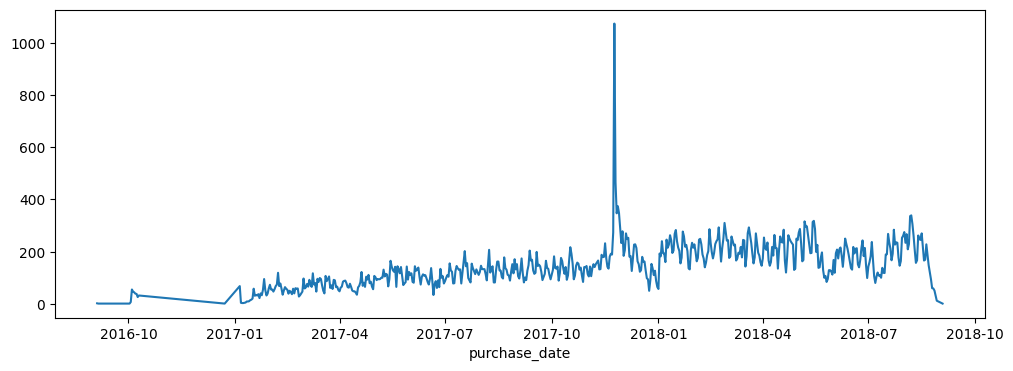

In [52]:
daily_orders.plot(figsize=(12, 4))

<Axes: xlabel='purchase_date'>

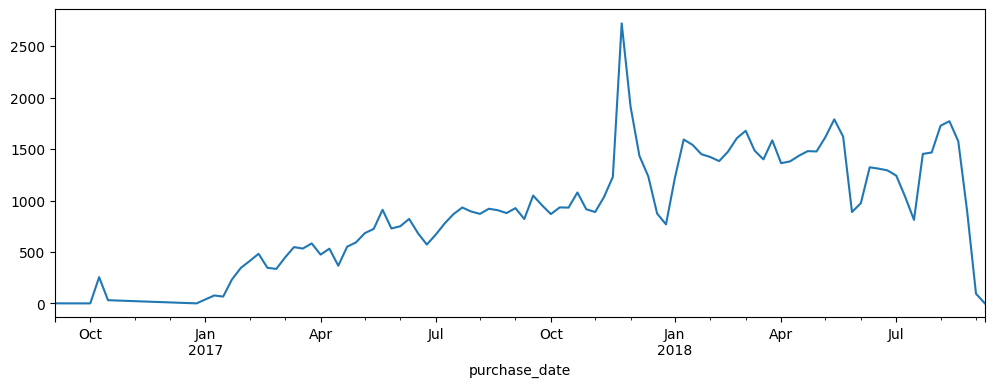

In [54]:
weekly_orders.plot(figsize=(12, 4))

<Axes: xlabel='purchase_date'>

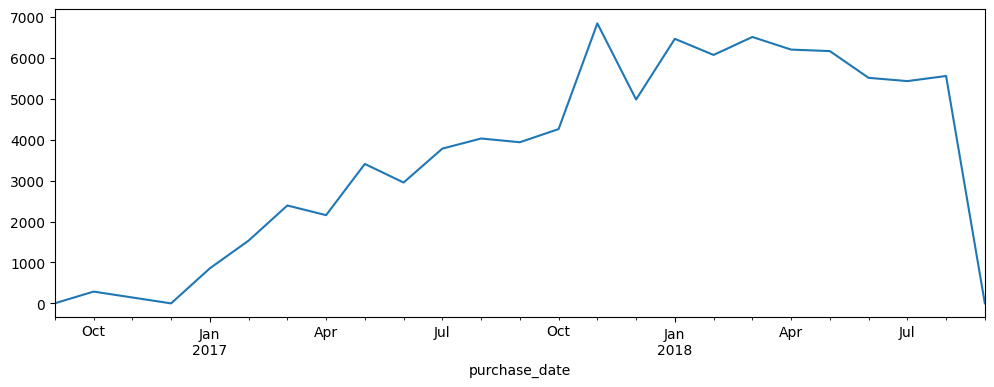

In [55]:
monthly_orders.plot(figsize=(12, 4))

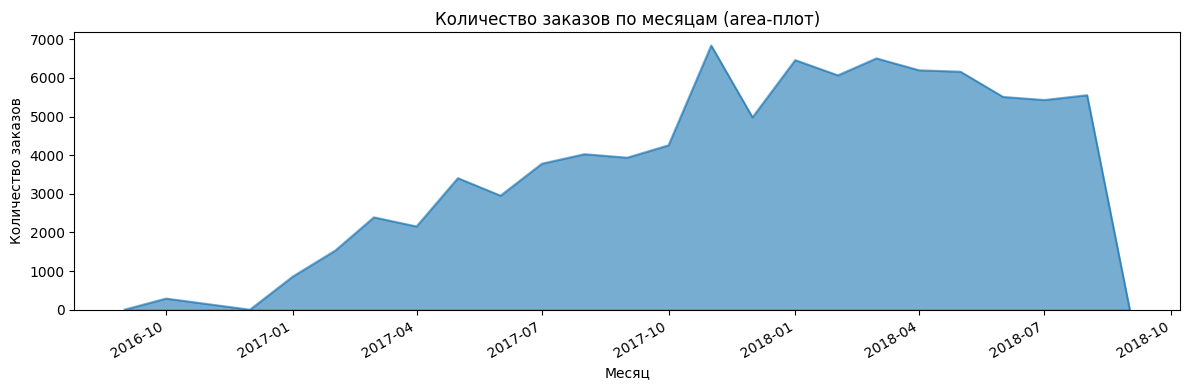

In [57]:
monthly_orders.index = monthly_orders.index.to_timestamp()

monthly_orders.plot(
    kind='area',
    figsize=(12, 4),
    alpha=0.6
)
plt.title('Количество заказов по месяцам (area-плот)')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.tight_layout()
plt.show()

In [78]:
df_orders['year'] = df_orders['purchase_date'].dt.year
df_orders['month'] = df_orders['purchase_date'].dt.month

df_orders_seasonal = df_orders[df_orders['year'] != 2016]

monthly_seasonal = (
    df_orders_seasonal
    .groupby(['year', 'month'])
    .size()
    .unstack('year')
    .sort_index()
)

monthly_seasonal


year,2017,2018
month,,
1,857.0,6463.0
2,1534.0,6069.0
3,2392.0,6508.0
4,2156.0,6200.0
5,3407.0,6163.0
6,2953.0,5510.0
7,3781.0,5430.0
8,4028.0,5555.0
9,3937.0,1.0


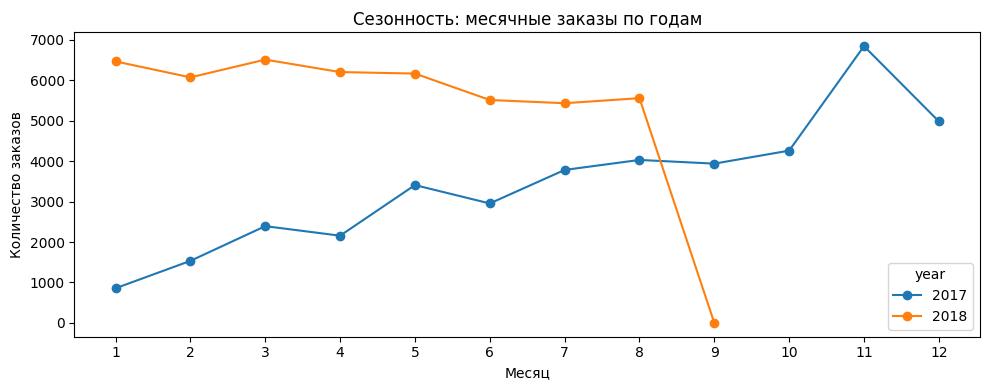

In [ ]:
monthly_seasonal.plot(
    kind='line',
    figsize=(10, 4),
    marker='o'
)
plt.xticks(ticks=range(1, 13))
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.title('Сезонность: месячные заказы по годам')
plt.tight_layout()
plt.show()


In [68]:
df_orders['customer_id'].isna().sum()

np.int64(0)

In [69]:
(df_orders['customer_id'] == '').sum()

np.int64(0)

In [71]:
df_orders['order_status'].unique()

<StringArray>
[  'delivered',    'canceled',     'shipped',  'processing',    'invoiced',
 'unavailable',    'approved']
Length: 7, dtype: str

In [72]:
df_orders['order_status'].value_counts().reset_index()

,order_status,count
0,delivered,87428
1,shipped,936
2,canceled,409
3,processing,273
4,invoiced,266
5,unavailable,2
6,approved,2


In [75]:
df_orders['purchase_to_delivered_days'] = (
    df_orders['delivered_date'] - df_orders['purchase_date']
) / np.timedelta64(1, 'D')

In [76]:
delivered_mask = df_orders['order_status'] == 'delivered'

delivery_stats = (
    df_orders.loc[delivered_mask, ['approved_to_delivered_days', 'purchase_to_delivered_days']]
    .agg(['count', 'mean', 'median'])
    .T
)

delivery_stats


,count,mean,median
approved_to_delivered_days,87413.0,12.001934,9.821875
purchase_to_delivered_days,87422.0,12.434251,10.193484


In [98]:
df_orders['purchase_hour'] = df_orders['purchase_date'].dt.hour

hourly_orders = (
    df_orders['purchase_hour']
    .value_counts()
    .sort_index()
)

hourly_orders_pct = (hourly_orders / hourly_orders.sum() * 100).round(2)

hourly_stats = pd.concat(
    [hourly_orders, hourly_orders_pct],
    axis=1
)
hourly_stats.columns = ['orders_count', 'orders_pct']
hourly_stats

,orders_count,orders_pct
purchase_hour,,
0,2199,2.46
1,999,1.12
2,471,0.53
3,249,0.28
4,215,0.24
5,180,0.20
6,486,0.54
7,1113,1.25
8,2732,3.06


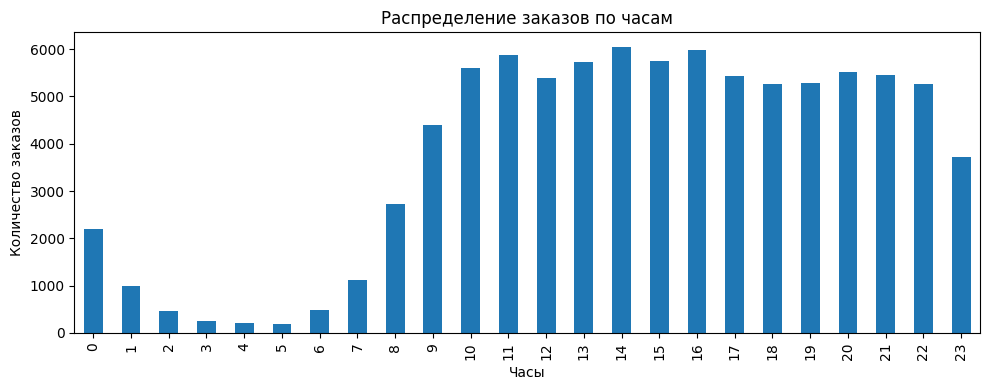

In [92]:
hourly_orders.plot(kind='bar', figsize=(10, 4))
plt.xlabel('Часы')
plt.ylabel('Количество заказов')
plt.title('Распределение заказов по часам')
plt.tight_layout()
plt.show()